## Мой спотик

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Настройки визуализации
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# ─────────────────────────────────────────────────────────────
# 1. ЗАГРУЗКА ДАННЫХ (без header, все колонки как строки сначала)
# ─────────────────────────────────────────────────────────────
df = pd.read_csv("dataset.csv", header=None, dtype=str)

# ─────────────────────────────────────────────────────────────
# 2. ОПРЕДЕЛЯЕМ ПРАВИЛЬНУЮ СТРУКТУРУ КОЛОНОК
# ─────────────────────────────────────────────────────────────
# На основе анализа датасета Spotify API
column_names = [
    "idx", "track_id", "artist", "album", "track_name", "popularity",
    "duration_ms", "explicit", "danceability", "energy", "key", "loudness",
    "mode", "speechiness", "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "time_signature", "genre"
]
df.columns = column_names

# ─────────────────────────────────────────────────────────────
# 3. ОЧИСТКА: удаляем строки с некорректным idx (?, !, !!)
# ─────────────────────────────────────────────────────────────
# Фильтруем только строки, где idx — число
df = df[df["idx"].str.match(r'^\d+$', na=False)]

# ─────────────────────────────────────────────────────────────
# 4. КОНВЕРТАЦИЯ ТИПОВ ДАННЫХ
# ─────────────────────────────────────────────────────────────
numeric_cols = ["popularity", "duration_ms", "danceability", "energy", 
                "loudness", "speechiness", "acousticness", "instrumentalness",
                "liveness", "valence", "tempo", "time_signature"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Конвертация boolean
df["explicit"] = df["explicit"].map({"True": True, "False": False})

# ─────────────────────────────────────────────────────────────
# 5. УДАЛЕНИЕ ПРОПУСКОВ
# ─────────────────────────────────────────────────────────────
df = df.dropna(subset=["popularity"])

print(f"✅ Размер датасета после очистки: {df.shape}")
print(f"\n📊 Статистика popularity:\n{df['popularity'].describe()}")

✅ Размер датасета после очистки: (114000, 21)

📊 Статистика popularity:
count    114000.000000
mean         33.238535
std          22.305078
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64


In [3]:
print(f"Размер датасета: {df.shape}")
print(f"\nПропуски:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nТипы данных:\n{df.dtypes}")
df.head(3)

Размер датасета: (114000, 21)

Пропуски:
artist        1
album         1
track_name    1
dtype: int64

Типы данных:
idx                     str
track_id                str
artist                  str
album                   str
track_name              str
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                     str
loudness            float64
mode                    str
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
genre                   str
dtype: object


,idx,track_id,artist,album,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,genre
1,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,...,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
2,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,...,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
3,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,...,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


count    114000.000000
mean         33.238535
std          22.305078
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64


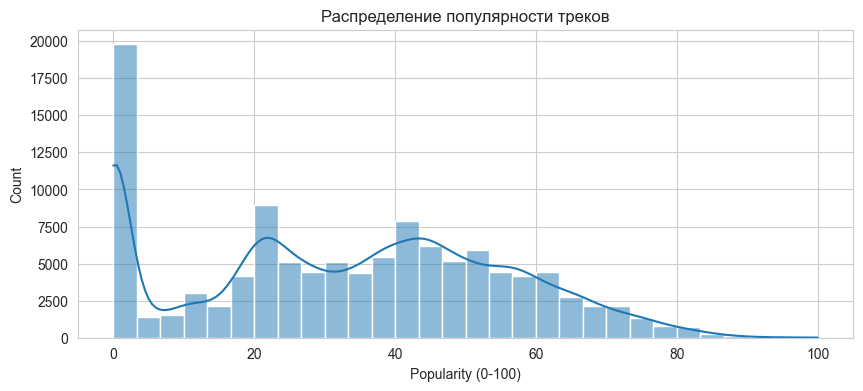

In [4]:
# Статистика popularity
print(df["popularity"].describe())

# Распределение таргета
plt.figure(figsize=(10, 4))
sns.histplot(df["popularity"], bins=30, kde=True)
plt.title("Распределение популярности треков")
plt.xlabel("Popularity (0-100)")
plt.show()

# Квантили для сегментации
df["pop_group"] = pd.qcut(df["popularity"], q=4, labels=["Low", "Medium", "High", "Very High"])

### Жанры и популярность

Топ-10 жанров по средней популярности:
             mean  median  count
genre                           
pop-film   59.283    60.0   1000
k-pop      56.896    60.0   1000
chill      53.651    57.0   1000
sad        52.379    54.0   1000
grunge     49.594    55.0   1000
indian     49.539    49.0   1000
anime      48.772    50.0   1000
emo        48.128    51.0   1000
sertanejo  47.866    47.0   1000
pop        47.576    66.0   1000


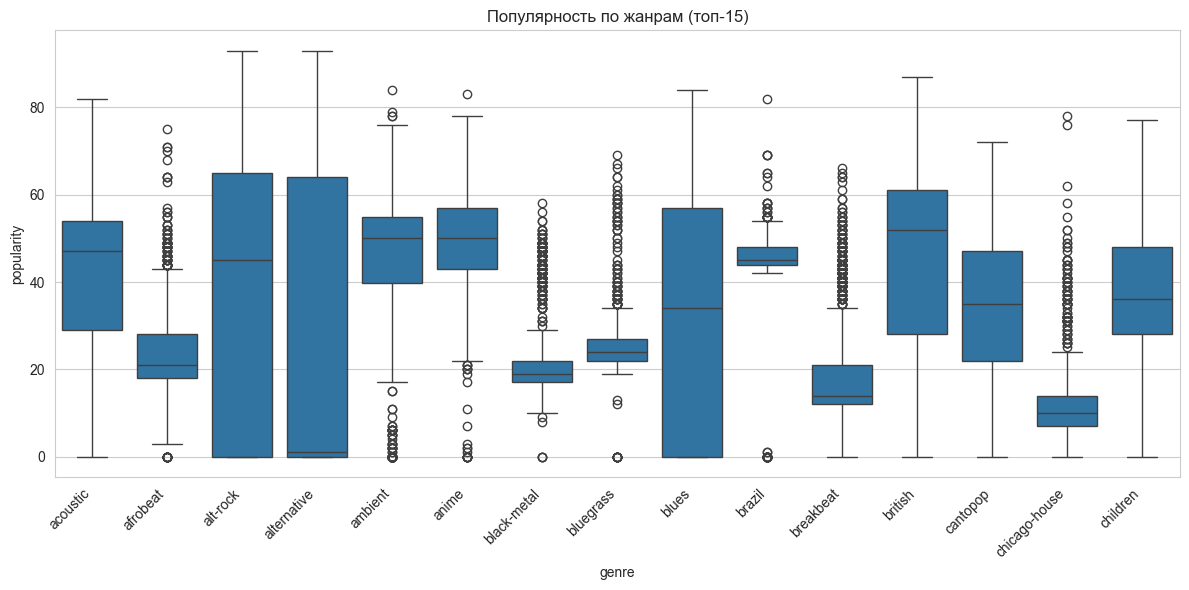

In [5]:
genre_pop = df.groupby("genre")["popularity"].agg(["mean", "median", "count"]).sort_values("mean", ascending=False)
print("Топ-10 жанров по средней популярности:")
print(genre_pop.head(10))

# Визуализация топ-15 жанров
top_genres = df["genre"].value_counts().nlargest(15).index
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[df["genre"].isin(top_genres)], x="genre", y="popularity")
plt.xticks(rotation=45, ha="right")
plt.title("Популярность по жанрам (топ-15)")
plt.tight_layout()
plt.show()

### Явные треки (explicit) популярнее?

               mean  median        std   count
explicit                                      
False     32.937891    34.0  22.083771  104253
True      36.454191    37.0  24.317510    9747

T-test: t=14.898, p-value=0.0000
Разница в средних: 3.52


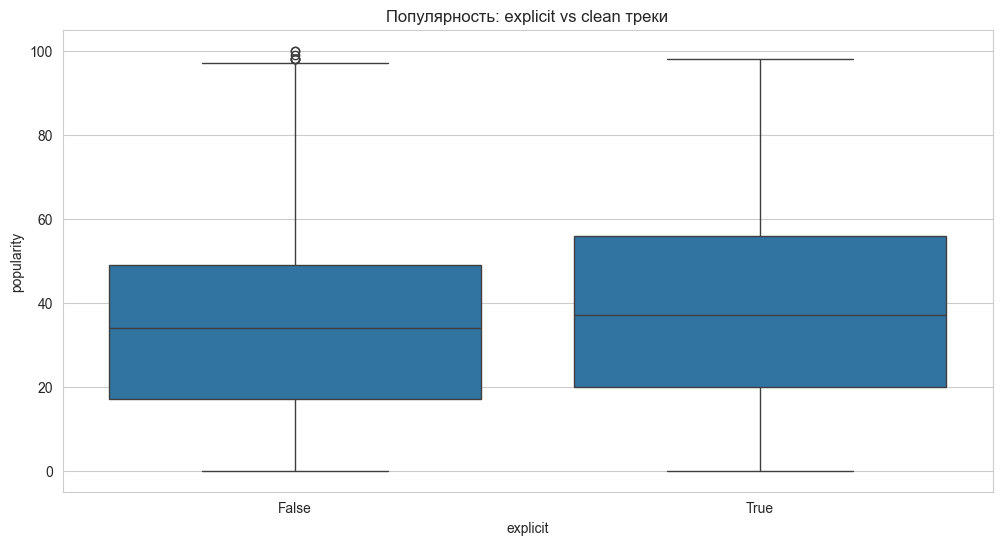

In [6]:
explicit_stats = df.groupby("explicit")["popularity"].agg(["mean", "median", "std", "count"])
print(explicit_stats)

# T-test для проверки значимости
t_stat, p_val = stats.ttest_ind(
    df[df["explicit"] == True]["popularity"],
    df[df["explicit"] == False]["popularity"]
)
print(f"\nT-test: t={t_stat:.3f}, p-value={p_val:.4f}")
print(f"Разница в средних: {df[df['explicit']==True]['popularity'].mean() - df[df['explicit']==False]['popularity'].mean():.2f}")

# Визуализация
sns.boxplot(data=df, x="explicit", y="popularity")
plt.title("Популярность: explicit vs clean треки")
plt.show()

### Аудио-фичи и популярность (корреляции)

Корреляция аудио-фич с популярностью:
popularity          1.000000
loudness            0.050423
danceability        0.035448
tempo               0.013205
energy              0.001056
liveness           -0.005387
acousticness       -0.025472
valence            -0.040534
speechiness        -0.044927
instrumentalness   -0.095139
Name: popularity, dtype: float64


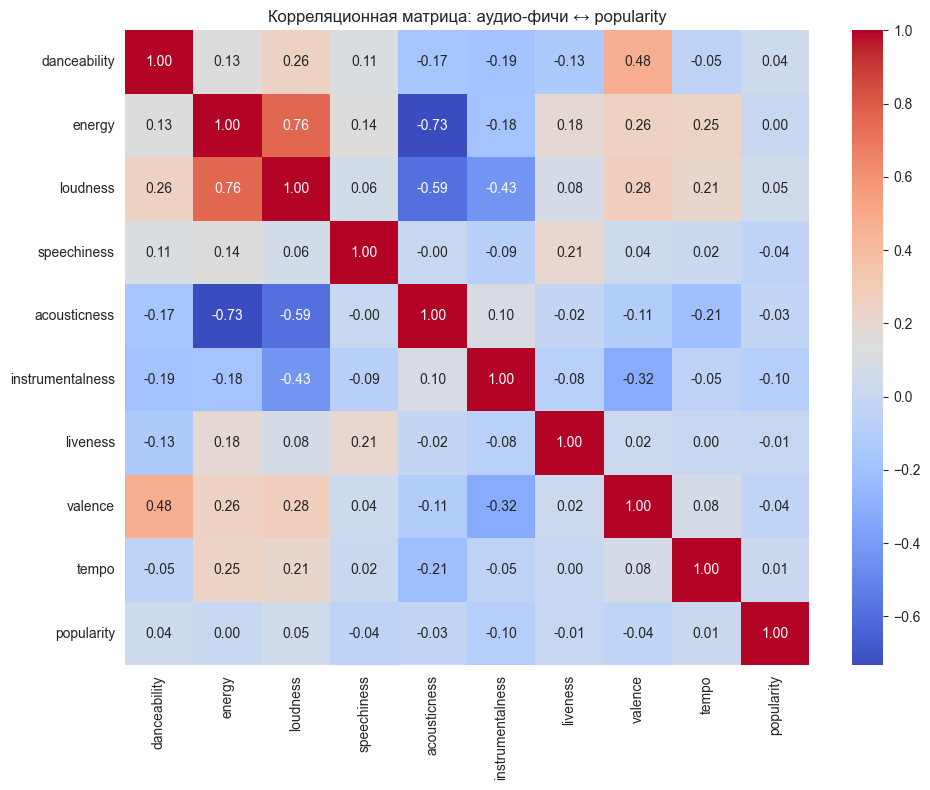

In [7]:
# Выбираем числовые фичи для корреляции
audio_features = ["danceability", "energy", "loudness", "speechiness", 
                  "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

corr_matrix = df[audio_features + ["popularity"]].corr()["popularity"].sort_values(ascending=False)
print("Корреляция аудио-фич с популярностью:")
print(corr_matrix)

# Heatmap корреляций
plt.figure(figsize=(10, 8))
sns.heatmap(df[audio_features + ["popularity"]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляционная матрица: аудио-фичи ↔ popularity")
plt.tight_layout()
plt.show()

### Длительность трека

Средняя популярность по длительности:
duration_group
<2min     28.394507
2-3min    32.113904
3-4min    34.677001
4+min     33.347046
Name: popularity, dtype: float64


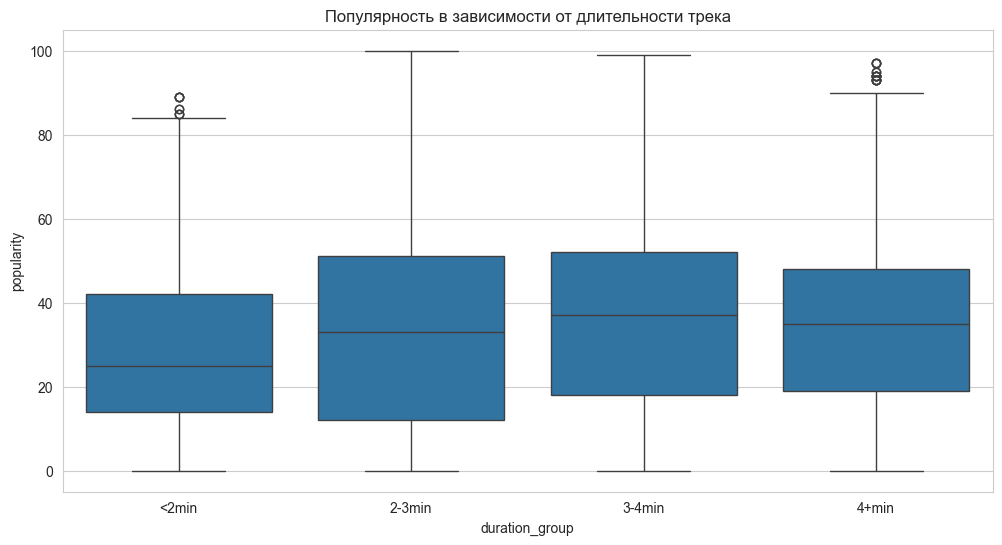

In [8]:
df["duration_min"] = df["duration_ms"] / 60000

# Сегментация по длительности
df["duration_group"] = pd.cut(df["duration_min"], bins=[0, 2, 3, 4, 10], labels=["<2min", "2-3min", "3-4min", "4+min"])
dur_pop = df.groupby("duration_group")["popularity"].mean()
print("Средняя популярность по длительности:")
print(dur_pop)

# Визуализация
sns.boxplot(data=df, x="duration_group", y="popularity")
plt.title("Популярность в зависимости от длительности трека")
plt.show()

### Темп (BPM) и популярность

Популярность по темпу:
                  mean  median  count
tempo_group                          
Slow         32.423515    33.0  16245
Medium       33.351103    34.0  36935
Fast         33.460948    35.0  40753
Very Fast    33.299638    34.0  19330


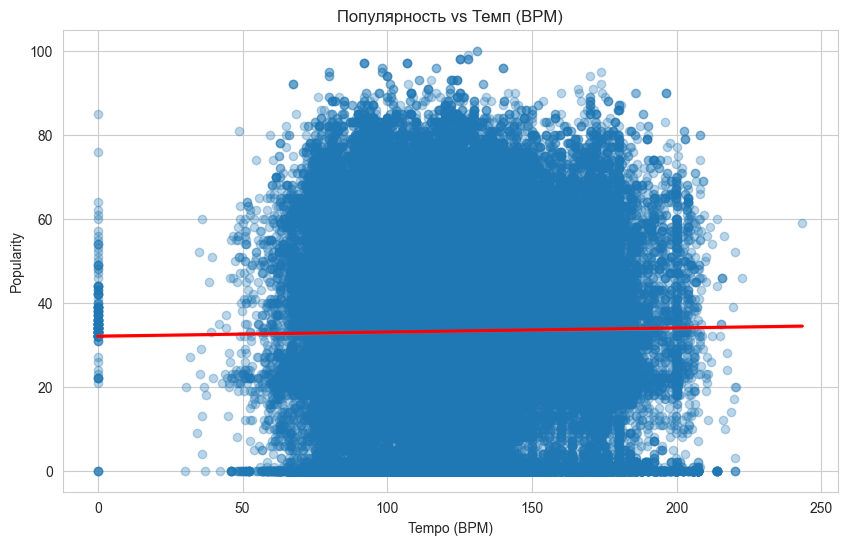

In [9]:
# Сегментация по темпу
df["tempo_group"] = pd.cut(df["tempo"], bins=[0, 90, 120, 150, 200], labels=["Slow", "Medium", "Fast", "Very Fast"])
tempo_pop = df.groupby("tempo_group")["popularity"].agg(["mean", "median", "count"])
print("Популярность по темпу:")
print(tempo_pop)

# Scatter с регрессией
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x="tempo", y="popularity", scatter_kws={"alpha": 0.3}, line_kws={"color": "red"})
plt.title("Популярность vs Темп (BPM)")
plt.xlabel("Tempo (BPM)")
plt.ylabel("Popularity")
plt.show()